# **OctWave 3.0 - Credit Card Fraud Detection Challenge**
### End-to-End Solution: **EDA** → **Feature Engineering** → **Model Comparison** → **Threshold Tuning** → **Final Submission**
**Author:** Yasandu Kethmika

**Evaluation Metric:** F1-score (fraud is rare, so precision/recall trade off matters more than raw accuracy)

**Approach summary:**
1. Explore the data and understand what actually separates fraud from legitimate transactions
2. Engineer a handful of domain informed features (night time flag, combined risk flag count, low device trust, high velocity)
3. Compare four models (Logistic Regression, Random Forest, XGBoost, LightGBM) with **stratified 5 fold cross validation**, not a single train/val split with only ~121 fraud rows in the whole training set, a single split is noisy and can be misleading
4. Pick the best model based on cross validated F1, then tune the classification **threshold** using out of fold (OOF) predictions, since F1 is threshold sensitive and the default 0.5 cutoff is rarely optimal for imbalanced problems
5. Retrain on the full training set and generate the submission file


In [ ]:
!pip install -q gdown

import gdown

gdown.download(id="1yq591dczG3fnrctZsmC47jPYly3-JZ1j", output="train.csv", quiet=False)
gdown.download(id="1aAmADBqiO8pLFERkeFOM4gdxVSVmXzPQ", output="test.csv", quiet=False)
gdown.download(id="1LaKrbA4ejKEjVrv9aOK2vJU0dIcXRvgV", output="sample_submission.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1yq591dczG3fnrctZsmC47jPYly3-JZ1j
To: /content/train.csv
100%|██████████| 289k/289k [00:00<00:00, 76.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aAmADBqiO8pLFERkeFOM4gdxVSVmXzPQ
To: /content/test.csv
100%|██████████| 68.1k/68.1k [00:00<00:00, 56.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LaKrbA4ejKEjVrv9aOK2vJU0dIcXRvgV
To: /content/sample_submission.csv
100%|██████████| 13.8k/13.8k [00:00<00:00, 29.5MB/s]


'sample_submission.csv'

In [ ]:
# ===== Imports =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_curve, auc
)

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## **1. Load the Data**

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (8000, 10)
Test shape : (2000, 9)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,6403,40.96,6,Food,0,1,82,2,51,0
1,5803,57.07,6,Electronics,0,0,42,2,18,0
2,4132,44.24,0,Grocery,0,0,26,2,25,0
3,7627,396.80,23,Clothing,0,0,97,1,34,0
4,6047,20.13,0,Food,0,0,91,1,28,0


In [ ]:
# Basic sanity checks
print("Missing values in train:\n", train.isna().sum())
print("\nMissing values in test:\n", test.isna().sum())
print("\nDuplicate rows in train:", train.duplicated().sum())
print("Any transaction_id overlap between train/test:",
      len(set(train.transaction_id) & set(test.transaction_id)))
print("\nDtypes:\n", train.dtypes)


Missing values in train:
 transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Missing values in test:
 transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
dtype: int64

Duplicate rows in train: 0
Any transaction_id overlap between train/test: 0

Dtypes:
 transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


## **2. Exploratory Data Analysis**

### 2.1 Class Imbalance
This is the single most important fact about this dataset - fraud is rare. This is *why* the competition
uses F1-score instead of accuracy: a model that predicts "not fraud" for everything would still score ~98.5%
accuracy while being completely useless.

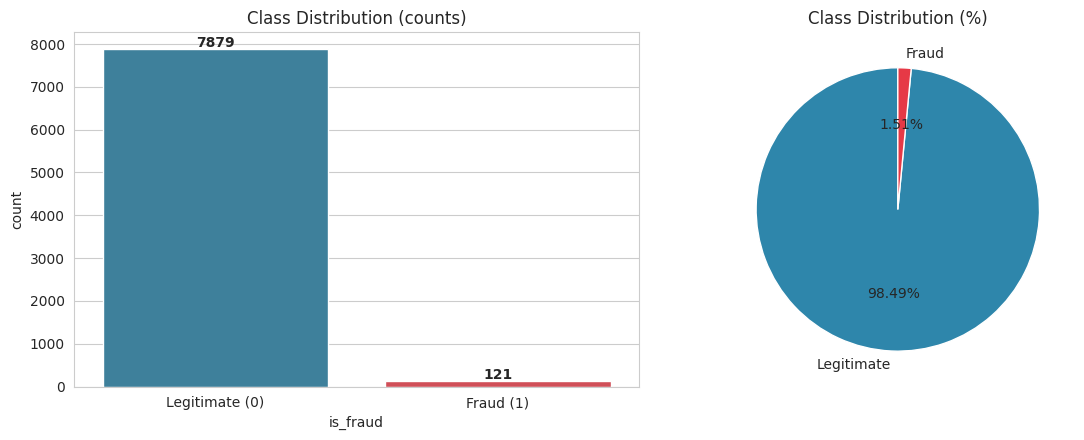

Fraud rate: 1.512%  (121 fraud out of 8000 total)


In [ ]:
fraud_counts = train["is_fraud"].value_counts()
fraud_pct = train["is_fraud"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x="is_fraud", data=train, palette=["#2E86AB", "#E63946"], ax=axes[0])
axes[0].set_title("Class Distribution (counts)")
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
for i, v in enumerate(fraud_counts.sort_index()):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(fraud_pct.sort_index(), labels=["Legitimate", "Fraud"],
            autopct="%1.2f%%", colors=["#2E86AB", "#E63946"], startangle=90)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

print(f"Fraud rate: {fraud_pct[1]:.3f}%  ({fraud_counts[1]} fraud out of {len(train)} total)")


### **2.2 Numeric Feature Distributions by Class**
How does each numeric feature differ between legitimate and fraudulent transactions?

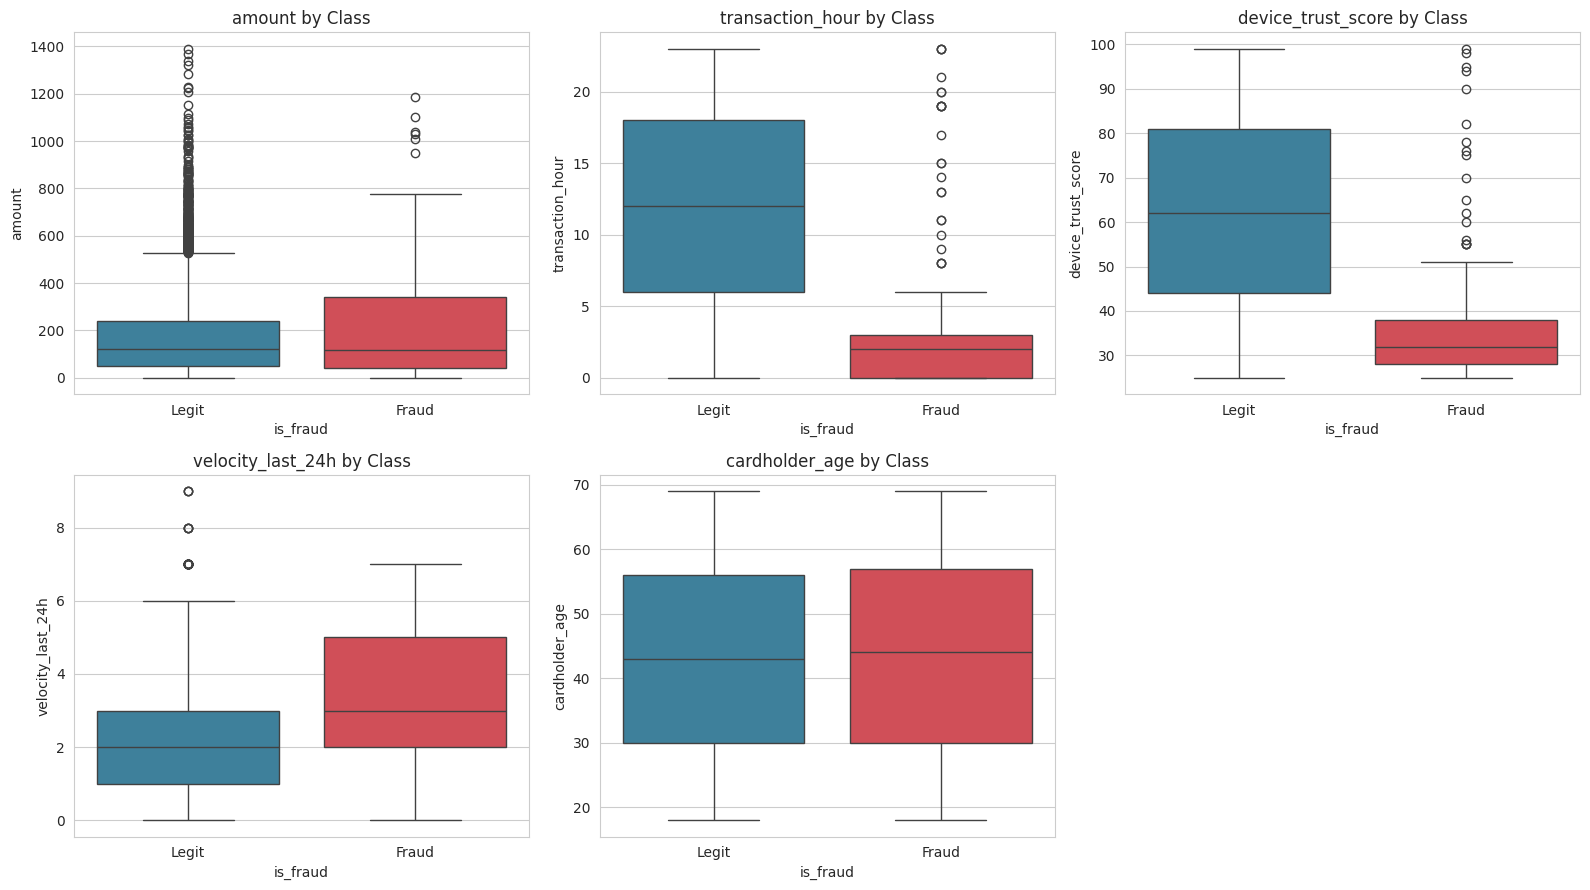

In [ ]:
numeric_cols = ["amount", "transaction_hour", "device_trust_score",
                 "velocity_last_24h", "cardholder_age"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x="is_fraud", y=col, data=train, palette=["#2E86AB", "#E63946"], ax=axes[i])
    axes[i].set_title(f"{col} by Class")
    axes[i].set_xticklabels(["Legit", "Fraud"])

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### **2.3 Binary Risk Flags: `foreign_transaction` and `location_mismatch`**
These look like the strongest signals in the dataset,  let's confirm.

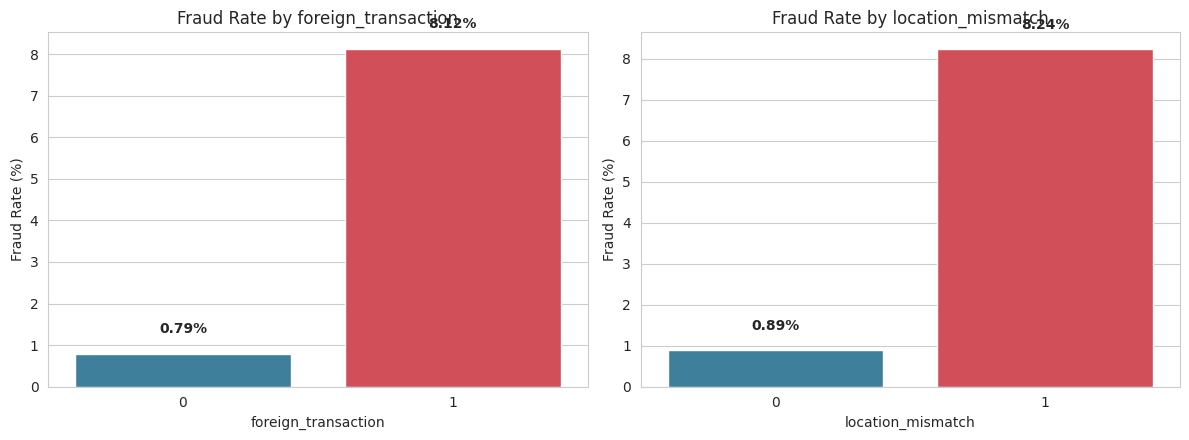

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, col in enumerate(["foreign_transaction", "location_mismatch"]):
    rate = train.groupby(col)["is_fraud"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, palette=["#2E86AB", "#E63946"], ax=axes[i])
    axes[i].set_title(f"Fraud Rate by {col}")
    axes[i].set_ylabel("Fraud Rate (%)")
    axes[i].set_xlabel(col)
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


### **2.4 Merchant Category vs Fraud Rate**

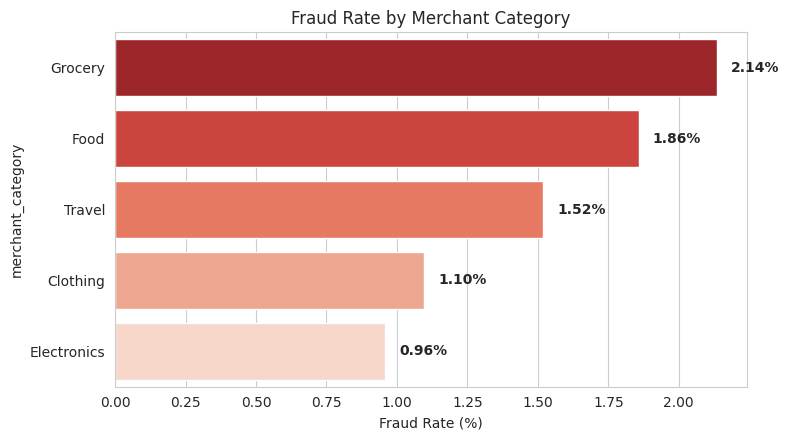

In [ ]:
cat_rate = train.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4.5))
sns.barplot(x=cat_rate.values, y=cat_rate.index, palette="Reds_r")
plt.xlabel("Fraud Rate (%)")
plt.title("Fraud Rate by Merchant Category")
for i, v in enumerate(cat_rate.values):
    plt.text(v + 0.05, i, f"{v:.2f}%", va="center", fontweight="bold")
plt.tight_layout()
plt.show()


### **2.5 Correlation Heatmap**

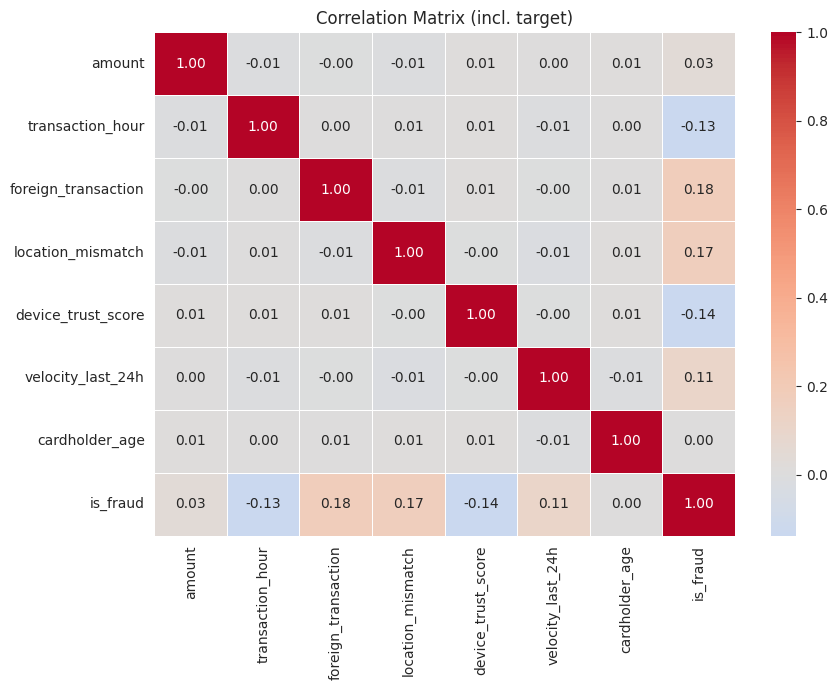

In [ ]:
corr_cols = ["amount", "transaction_hour", "foreign_transaction", "location_mismatch",
             "device_trust_score", "velocity_last_24h", "cardholder_age", "is_fraud"]

plt.figure(figsize=(9, 7))
sns.heatmap(train[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5)
plt.title("Correlation Matrix (incl. target)")
plt.tight_layout()
plt.show()


### **EDA takeaways:**
- Fraud rate is **~1.5%** - strong class imbalance, F1/threshold tuning matters a lot
- `foreign_transaction=1` and `location_mismatch=1` transactions have **~8% fraud rate** vs <1% otherwise: by far the strongest signals
- Fraud transactions happen disproportionately at **night** (low `transaction_hour`) and on devices with **low `device_trust_score`**
- `velocity_last_24h` is mildly elevated for fraud
- `amount`, `cardholder_age`, and `merchant_category` show weak/no relationship with fraud on their own

## **3. Feature Engineering**

Based on the EDA above, I engineer a few domain informed features on top of the raw ones:
- `is_night`: transaction happened between midnight and 5 a.m. (fraud is night heavy)
- `risk_flag_sum`: sum of `foreign_transaction` + `location_mismatch` (0, 1, or 2 combined risk)
- `low_trust`: device trust score below 40 (fraud clusters at low trust)
- `high_velocity`: 4+ transactions in the last 24h
- `amount_log`: log transform of amount to reduce skew
- One hot encode `merchant_category`


In [ ]:
def engineer_features(df):
    df = df.copy()
    df["is_night"] = df["transaction_hour"].between(0, 5).astype(int)
    df["risk_flag_sum"] = df["foreign_transaction"] + df["location_mismatch"]
    df["low_trust"] = (df["device_trust_score"] < 40).astype(int)
    df["high_velocity"] = (df["velocity_last_24h"] >= 4).astype(int)
    df["amount_log"] = np.log1p(df["amount"])
    df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)
    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

# Align test columns to train columns (in case a category is missing in test)
feature_cols = [c for c in train_fe.columns if c not in ["is_fraud", "transaction_id"]]
test_fe = test_fe.reindex(columns=feature_cols, fill_value=0)

X = train_fe[feature_cols]
y = train_fe["is_fraud"]
X_test_final = test_fe[feature_cols]

print("Feature columns:", feature_cols)
print("X shape:", X.shape, " | X_test shape:", X_test_final.shape)


Feature columns: ['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_night', 'risk_flag_sum', 'low_trust', 'high_velocity', 'amount_log', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']
X shape: (8000, 16)  | X_test shape: (2000, 16)


## **4. Train / Validation Split**
Used for the confusion matrix / ROC visuals below. The final model (Section 6) is trained with proper
**stratified cross validation**, not this single split, since one split is noisy with only ~121 fraud rows total.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Fraud rate:", y_train.mean().round(4))
print("Val  :", X_val.shape, " Fraud rate:", y_val.mean().round(4))


Train: (6400, 16)  Fraud rate: 0.0152
Val  : (1600, 16)  Fraud rate: 0.015


## **5. Model Comparison : Stratified 5 Fold Cross-Validation**

I compare four models. For each fold, I find the **F1-optimal threshold** on the validation fold's
precision-recall curve (rather than defaulting to 0.5), since that's what actually matters for
this competition's metric.

In [ ]:
def best_f1_and_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return f1_scores[best_idx], best_thresh

def cross_val_f1(model_fn, X, y, n_splits=5, scale=False, set_spw=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    for tr_idx, val_idx in skf.split(X, y):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[val_idx]

        if scale:
            scaler = StandardScaler()
            Xtr = scaler.fit_transform(Xtr)
            Xva = scaler.transform(Xva)

        model = model_fn(ytr) if set_spw else model_fn()
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xva)[:, 1]
        f1, _ = best_f1_and_threshold(yva, proba)
        fold_scores.append(f1)
    return fold_scores

results = {}

results["Logistic Regression"] = cross_val_f1(
    lambda: LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    X, y, scale=True
)

results["Random Forest"] = cross_val_f1(
    lambda: RandomForestClassifier(n_estimators=400, max_depth=8, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1),
    X, y
)

results["XGBoost"] = cross_val_f1(
    lambda ytr: xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(ytr == 0).sum() / (ytr == 1).sum()
    ),
    X, y, set_spw=True
)

results["LightGBM"] = cross_val_f1(
    lambda: lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1),
    X, y
)

results_df = pd.DataFrame({m: {"mean_f1": np.mean(s), "std_f1": np.std(s)} for m, s in results.items()}).T
results_df = results_df.sort_values("mean_f1", ascending=False)
print(results_df)


                      mean_f1    std_f1
LightGBM             0.995745  0.008511
XGBoost              0.987411  0.016712
Random Forest        0.965379  0.018240
Logistic Regression  0.829723  0.050462


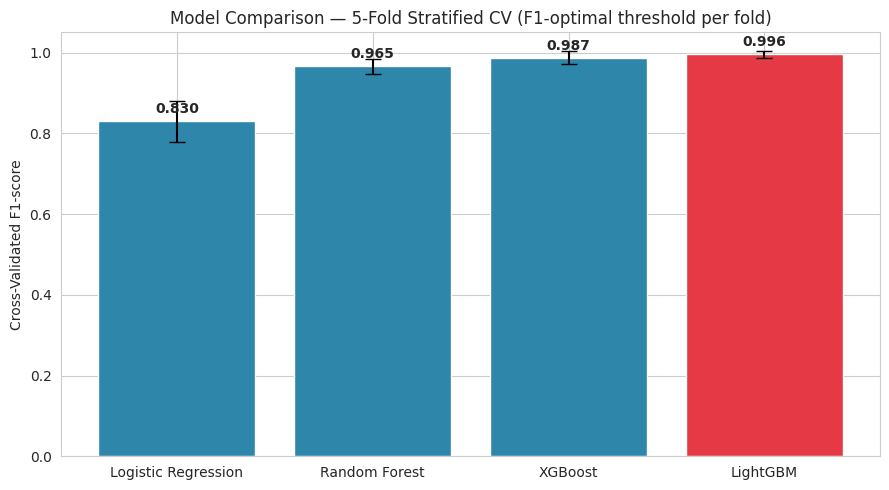


Best model: LightGBM  (mean CV F1 = 0.9957)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
means = [np.mean(results[m]) for m in results]
stds = [np.std(results[m]) for m in results]
colors = ["#E63946" if m == results_df.index[0] else "#2E86AB" for m in results]

bars = ax.bar(results.keys(), means, yerr=stds, capsize=6, color=colors)
ax.set_ylabel("Cross-Validated F1-score")
ax.set_title("Model Comparison — 5-Fold Stratified CV (F1-optimal threshold per fold)")
ax.set_ylim(0, 1.05)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.02, f"{m:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nBest model: {results_df.index[0]}  (mean CV F1 = {results_df.iloc[0]['mean_f1']:.4f})")


## **6. Final Model: Out of Fold Predictions & Threshold Tuning**

LightGBM comes out on top. To pick a threshold that will generalize (rather than one that overfits a
single validation fold), I generate **out-of-fold (OOF) predictions** across the full training set
every row gets a prediction from a fold it was *not* trained on and tune the threshold on those.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(X))

for tr_idx, val_idx in skf.split(X, y):
    Xtr, Xva = X.iloc[tr_idx], X.iloc[val_idx]
    ytr = y.iloc[tr_idx]
    model = lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1)
    model.fit(Xtr, ytr)
    oof_proba[val_idx] = model.predict_proba(Xva)[:, 1]

oof_f1, best_threshold = best_f1_and_threshold(y, oof_proba)
print(f"Out-of-fold F1: {oof_f1:.4f}")
print(f"Best threshold: {best_threshold:.4f}")


Out-of-fold F1: 0.9959
Best threshold: 0.6600


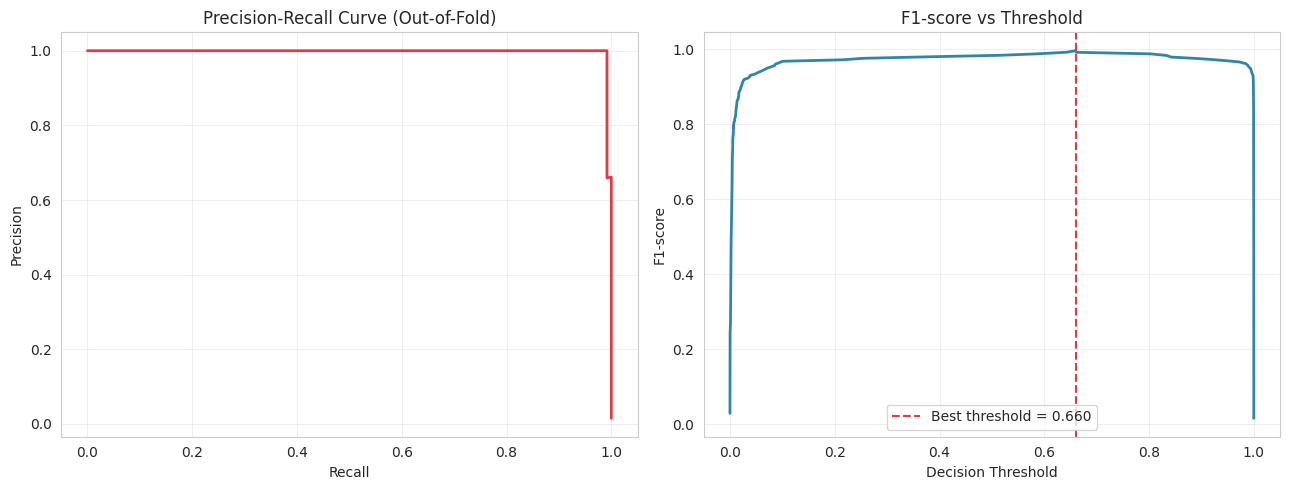

In [ ]:
precision, recall, thresholds = precision_recall_curve(y, oof_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall, precision, color="#E63946", linewidth=2)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Out-of-Fold)")
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_scores[:-1], color="#2E86AB", linewidth=2)
axes[1].axvline(best_threshold, color="#E63946", linestyle="--",
                 label=f"Best threshold = {best_threshold:.3f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("F1-score")
axes[1].set_title("F1-score vs Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### **6.1 Confusion Matrix & Classification Report (at best threshold, OOF predictions)**

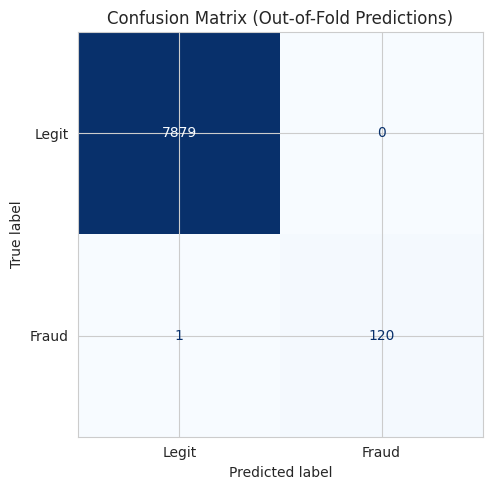

              precision    recall  f1-score   support

       Legit     0.9999    1.0000    0.9999      7879
       Fraud     1.0000    0.9917    0.9959       121

    accuracy                         0.9999      8000
   macro avg     0.9999    0.9959    0.9979      8000
weighted avg     0.9999    0.9999    0.9999      8000



In [ ]:
oof_pred = (oof_proba >= best_threshold).astype(int)

cm = confusion_matrix(y, oof_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (Out-of-Fold Predictions)")
plt.tight_layout()
plt.show()

print(classification_report(y, oof_pred, target_names=["Legit", "Fraud"], digits=4))


### **6.2 ROC Curve (Out-of-Fold)**

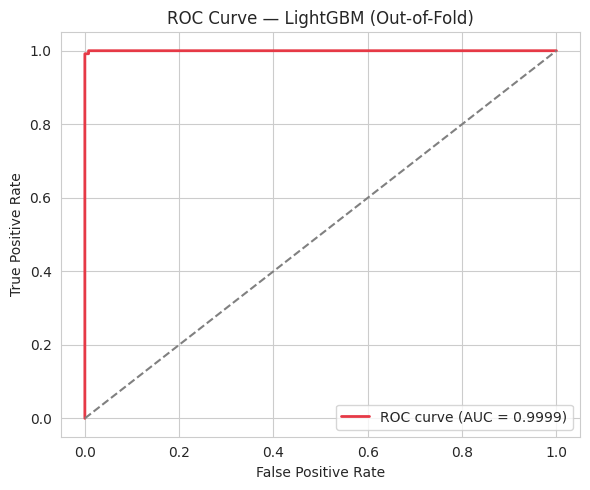

In [ ]:
fpr, tpr, _ = roc_curve(y, oof_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#E63946", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM (Out-of-Fold)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## **7. Feature Importance**
Trained on the full training set, to see which features the final model relies on most.

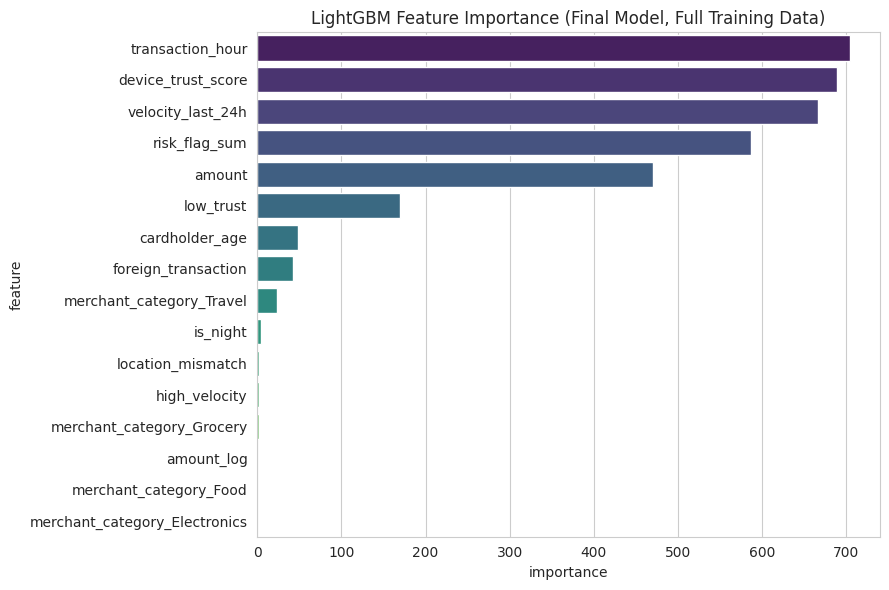

,feature,importance
1,transaction_hour,705
4,device_trust_score,689
5,velocity_last_24h,666
8,risk_flag_sum,587
0,amount,470
9,low_trust,170
6,cardholder_age,48
2,foreign_transaction,43
15,merchant_category_Travel,24
7,is_night,4


In [ ]:
final_model = lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1)
final_model.fit(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x="importance", y="feature", data=importance_df, palette="viridis")
plt.title("LightGBM Feature Importance (Final Model, Full Training Data)")
plt.tight_layout()
plt.show()

importance_df


## **8. Generate Final Predictions on Test Set**

The final model was already trained on the **full** training set in Section 7 (`final_model`).
I apply the OOF tuned threshold to its test set probabilities.

In [ ]:
test_proba = final_model.predict_proba(X_test_final)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    "transaction_id": test["transaction_id"],
    "is_fraud": test_pred
})

# Sanity checks before saving
assert submission.shape[0] == sample_submission.shape[0], "Row count mismatch with sample_submission!"
assert set(submission["transaction_id"]) == set(sample_submission["transaction_id"]), "ID mismatch!"
assert set(submission["is_fraud"].unique()).issubset({0, 1}), "Non-binary predictions!"

print("Predicted fraud rate on test set:", submission["is_fraud"].mean().round(4))
print("Predicted fraud count:", submission["is_fraud"].sum(), "out of", len(submission))

submission.to_csv("submission.csv", index=False)
submission.head()


Predicted fraud rate on test set: 0.015
Predicted fraud count: 30 out of 2000


,transaction_id,is_fraud
0,9945,0
1,2602,0
2,343,0
3,3223,0
4,5217,0


## **9. Methodology Summary (for competition writeup)**

**Data:** 8,000 training transactions, 9 raw features, 1.51% fraud rate.

**Preprocessing / Feature Engineering:** No missing values or duplicates. Added 5 engineered features
(`is_night`, `risk_flag_sum`, `low_trust`, `high_velocity`, `amount_log`) derived from EDA-observed patterns,
plus one-hot encoded `merchant_category`.

**Class Imbalance Handling:** Used `class_weight="balanced"` (LightGBM/Random Forest/Logistic Regression)
or `scale_pos_weight` (XGBoost) rather than oversampling (e.g. SMOTE), since tree-based models with class
weighting handle this rare-event imbalance well without risking synthetic-sample artifacts.

**Model Selection:** Compared Logistic Regression, Random Forest, XGBoost, and LightGBM using stratified
5-fold cross-validation (critical here — only ~121 fraud rows total, so a single split is unreliable).
LightGBM had the highest and most consistent cross-validated F1.

**Threshold Tuning:** Rather than using the default 0.5 cutoff, I generated out-of-fold predictions across
the entire training set and selected the threshold that maximizes F1 on the precision-recall curve.

**Final Model:** LightGBM retrained on the full training set, using the OOF-tuned threshold to convert
probabilities to binary predictions on the test set.

**Reproducibility:** All randomness is seeded (`RANDOM_STATE = 42`) for reproducible results.
